### 1. Geometria rzutu (Pozycje na rozpiętości $y$)

Wszystkie wartości dotyczą **połowy rozpiętości** ($b/2 = 1.0\,m$).

- **`y_root` (0.05):** Szerokość kadłuba (wycięcie). Skrzydło zaczyna się 5 cm od osi symetrii.
    
- **`y_break_f` (0.3):** Pozycja profilu przejściowego. Obliczana jako 30% dystansu między kadłubem a końcówką.
    
- **`y_tip_f` (0.85):** Moment, w którym kończy się płaskie skrzydło i zaczyna wyginać się winglet (85% rozpiętości).
    

### 2. Cięciwy i Kształt (Szerokość $c$ i Skos $x$)

- **`c_root`, `c_brk`, `c_tip`:** Szerokość profilu kolejno u nasady (35 cm), w miejscu przejścia (25 cm) i na starcie wingletu (15 cm).
    
- **`x_brk` (0.1):** Skos w punkcie przejścia. Krawędź natarcia jest przesunięta o 10 cm w tył względem nasady.
    
- **`x_tip` (0.35):** Skos na końcówce. Krawędź natarcia jest 35 cm w tyle względem nasady (tworzy to strzałkę skrzydła).
    

### 3. Zwichrzenie i Wznios (Kąty $t$ i Wysokość $z$)

- **`t_root`, `t_brk`, `t_tip`:** Kąty skręcenia profilu (twist/washout). Tutaj: nasada jest zadarta o $1^{\circ}$, środek to $0^{\circ}$, a końcówka jest "odpuszczona" o $-2.5^{\circ}$ dla stabilności.
    
- **`z_brk`, `z_tip`:** Wznios (dihedral). Środek skrzydła jest 2 cm wyżej niż nasada, a końcówka 5 cm wyżej (tworzy kształt litery V).
    

### 4. Parametry Wingletu

- **`h_w` (0.15):** Całkowita wysokość wingletu (15 cm ponad płaszczyznę skrzydła). 
- **`R_w` (0.04):** Promień łuku (4 cm). Określa, jak łagodnie skrzydło przechodzi w pionowy winglet.
- **`c_w_end` (0.08):** Cięciwa na samym szczycie wingletu (zwężenie do 8 cm).
- **`sweep_w` (0.05):** Dodatkowy skos wingletu. Jego czubek jest 5 cm dalej w tyle niż jego podstawa. 
- **`toe` (1.5):** Kąt zbieżności. Winglet jest skręcony o $1.5^{\circ}$ "nosem do środka" kadłuba.
    

### 5. Wybór Profilu (Baza ID)

- **`id_root`, `id_brk`, `id_tip`, `id_w`:** Indeksy plików `.dat` w Twoim folderze. Na przykład `id_root: 3` oznacza, że u nasady zostanie użyty czwarty plik z listy (licząc od 0).

In [1]:
from solver import *

In [2]:
from pathlib import Path
import aerosandbox as asb
# --- PARAMETRY GLOBALNE ---
B = 1.2                 # Rozpiętość całkowita [m]
TARGET_VELOCITY = 15.0  # Prędkość przelotowa [m/s]
FIXED_MASS = 0.4        # Masa elektroniki i baterii [kg]
TOTAL_MASS = 1.0        # Docelowa masa całkowita [kg]
WING_DENSITY = 1.2      # Masa struktury skrzydła [kg/m2]
AIRFOIL_FOLDER = Path("./airfoils/") # Folder z plikami .dat

# Lista dostępnych profilów (załadowana raz na starcie)
def load_airfoils(folder):
    files = list(folder.glob("*.dat"))
    return {i: asb.Airfoil(name=f.stem, coordinates=f) for i, f in enumerate(files)}

AIRFOIL_DATABASE = load_airfoils(AIRFOIL_FOLDER)

In [3]:
asb.__version__

'4.2.9'

In [4]:
print(AIRFOIL_DATABASE)
print("Rozpiętość: ", B)
print("Prędkość przelotowa: ", TARGET_VELOCITY, "m/s")
print("Masa elektroniki i baterii: ", FIXED_MASS, "kg")
print("Gęstość struktury skrzydła: ", WING_DENSITY, "kg/m2")

{0: Airfoil AG25-il (160 points), 1: Airfoil AG35 (180 points), 2: Airfoil AG36 (180 points), 3: Airfoil AH 79-100 A (97 points), 4: Airfoil FX 60-100 (97 points), 5: Airfoil GOE 444 (33 points), 6: Airfoil NACA-0009 smoothed (69 points), 7: Airfoil RG-15 8.9% (62 points), 8: Airfoil S7012 8.75% (81 points), 9: Airfoil SD8020-010-88 (61 points)}
Rozpiętość:  1.2
Prędkość przelotowa:  15.0 m/s
Masa elektroniki i baterii:  0.4 kg
Gęstość struktury skrzydła:  1.2 kg/m2


In [5]:
test_genes ={
       "y_root": 0.0,
        "y_break_f": 0.2,
        "y_tip_f": 0.95,
        "c_root": 0.33,
        "c_brk": 0.1079295799543952,
        "c_tip": 0.10402214554386019,
        "t_root": 0.49795449196973374,
        "t_brk": -0.7563920819706146,
        "t_tip": -2.9889123613866033,
        "x_brk": 0.25,
        "x_tip": 0.34886888181632947,
        "z_brk": 0.06009143904844781,
        "z_tip": 0.0,
        "winglet_target_angle": 81.55204925241533,
        "h_w": 0.05,
        "R_w": 0.1,
        "c_w_end": 0.024005632917371456,
        "sweep_w": 0.0,
        "toe": 3.296572062778997,
        "id_root": 4.660112792039721,
        "id_brk": 3.810694053749041,
        "id_tip": 0.1578966055693487,
        "id_w": 8.780798089868503
}

airplane, mass = build_airplane_curved(test_genes, 'linear')
print(f"Samolot zbudowany pomyślnie! Szacowana masa: {mass:.3f} kg")
airplane.draw(backend='plotly')
alphas1 = np.linspace(-2, 15, 16)  # Zakres kątów natarcia
data, x_cg_target = GA_aerodynamics(airplane, TARGET_VELOCITY, alphas1)
score, score_details = fitness_function_weighted(data)
print(f"Score: {score:.2f}")
print(data)




Samolot zbudowany pomyślnie! Szacowana masa: 0.612 kg


Score: 70.48
{'ld': np.float64(24.059553042641394), 'cm_cg': np.float64(-0.002319057911439548), 'cma': np.float64(-0.3828160643747487), 'cnb': np.float64(0.3964744212335359), 'oswald': np.float64(0.9379274665625434), 'cmq': np.float64(-8.561985037501495), 'clp': np.float64(-0.5620686992361895), 'cnr': np.float64(0.006509577650018675), 'alpha': np.float64(4.801)}


In [6]:
results = analyze_aerodynamics(airplane, mass, TARGET_VELOCITY)
print(results)


{'ld': np.float64(20.000927477618358), 'sm': 0.08, 'cnb': np.float64(0.09055505936112461), 'cl': np.float64(0.36332771205250547), 'cd': np.float64(0.018165543195888298), 'cm_cg': np.float64(0.03686776135658165), 'mass': np.float64(0.6116385848854199), 'x_np': array([0.31014811]), 'x_cg': array([0.29839834]), 'obj': AeroBuildup(
	airplane=Airplane 'Untitled' (1 wing, 0 fuselages)
	op_point=OperatingPoint instance:
	State variables:
		atmosphere: Atmosphere (altitude: 0 m (0 ft), method: 'differentiable')                                                             
		  velocity: 15.0                                                                                                                    
		     alpha: 2.0                                                                                                                     
		      beta: 1.0                                                                                                                     
		         p: 0.0        

In [7]:
metrics = calculate_extra_metrics(airplane, mass, TARGET_VELOCITY)
print(f"--- GEOMETRIA ---")
print(f"Powierzchnia: {metrics['S [m^2]']:.3f} m2")
print(f"Rozpiętość: {metrics['Span']:.3f} m")
print(f"Aerodynamic Center: {metrics['Aerodynamic center']}")
print(f"AR: {metrics['AR']:.2f} (Efektywne: {metrics['AR_eff']:.2f})")
print(f"Taper Ratio: {metrics['Taper']:.2f}")
print(f"Oswald efficiency: {metrics['e']:.3f}")
print(f"Obciążenie: {metrics['Wing Loading [kg/m^2]']:.2f} kg/m2")
print(f"Re: {metrics['Re']:.0f}")
print(f"Mean Twist Angle: {metrics['MtA']:.2f} deg")
print(f"Mean Sweep Angle: {metrics['MsA']:.2f} deg")
print(f"Mean Dihedral Angle: {metrics['MdA']:.2f} deg")

--- GEOMETRIA ---
Powierzchnia: 0.176 m2
Rozpiętość: 1.493 m
Aerodynamic Center: [0.27544667 0.         0.02698385]
AR: 12.64 (Efektywne: 14.00)
Taper Ratio: 0.07
Oswald efficiency: 0.601
Obciążenie: 3.47 kg/m2
Re: 149104
Mean Twist Angle: -1.53 deg
Mean Sweep Angle: 21.47 deg
Mean Dihedral Angle: 7.07 deg


In [8]:
'''alphas = np.linspace(-5, 12, 30)

basic_aoa = basic_analysis(
    airplane=airplane,
    velocity=18,
    alphas=alphas
)'''

'alphas = np.linspace(-5, 12, 30)\n\nbasic_aoa = basic_analysis(\n    airplane=airplane,\n    velocity=18,\n    alphas=alphas\n)'

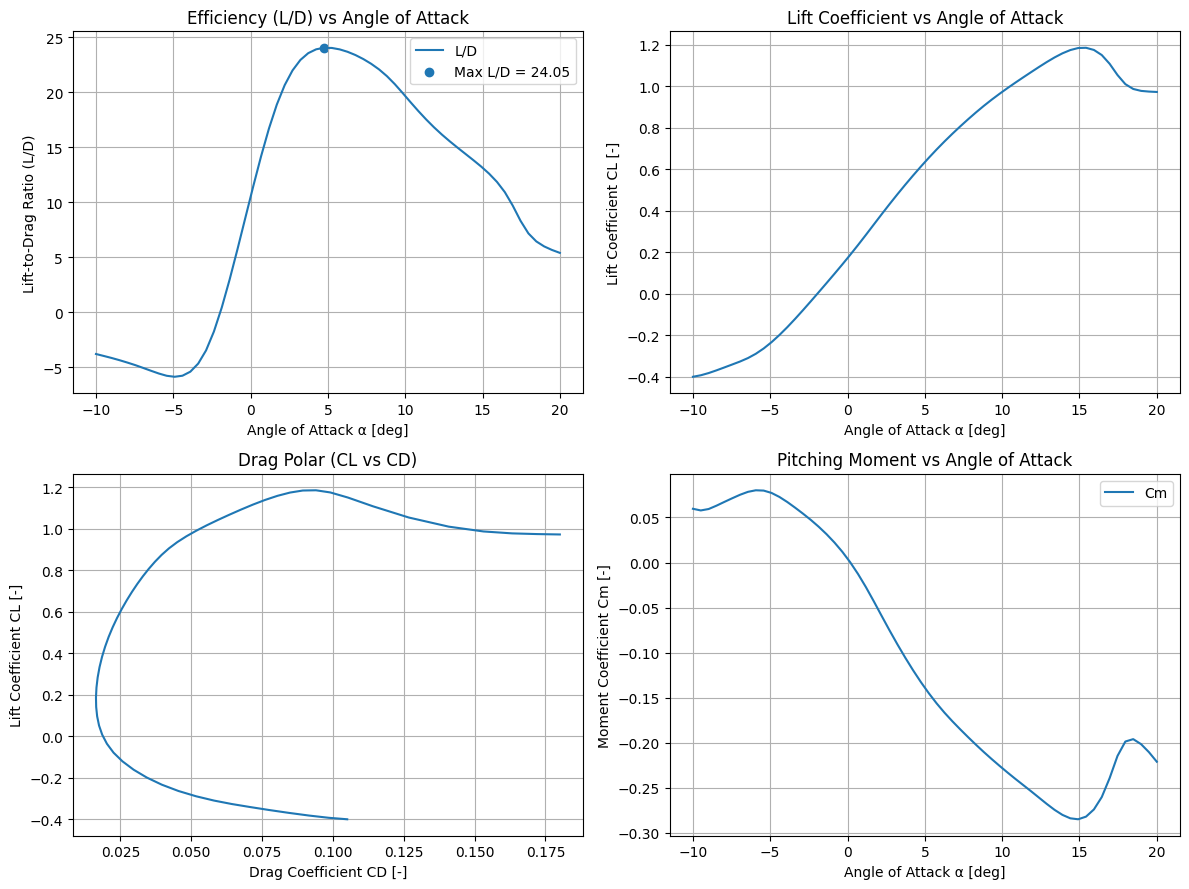


=== SUMMARY ===
Max L/D       : 24.05 at α = 4.75 deg
Oswald e      : 1.442


{'F_g': [array([ 0.82945464,  0.79016464,  0.75141018,  0.70927963,  0.6681606 ,
          0.63035837,  0.59329921,  0.55912755,  0.52597817,  0.49638651,
          0.47497599,  0.46152642,  0.45452474,  0.45184746,  0.45263075,
          0.45617703,  0.4580605 ,  0.45480101,  0.44327786,  0.42067068,
          0.38507772,  0.33521673,  0.27012683,  0.18924132,  0.09244153,
         -0.01998324, -0.14752862, -0.28965741, -0.44586916, -0.61569409,
         -0.79858784, -0.99376916, -1.20017704, -1.41669636, -1.64240301,
         -1.87623982, -2.11620785, -2.35894713, -2.60094758, -2.84125037,
         -3.08181229, -3.32470377, -3.57145761, -3.82403953, -4.08321833,
         -4.34671225, -4.60945823, -4.86433031, -5.10168286, -5.30693272,
         -5.4571276 , -5.52114558, -5.45681016, -5.19607715, -4.74486396,
         -4.31457649, -4.06926091, -3.97578173, -3.95836573, -3.968877  ]),
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0

In [9]:
alphaSweep = analyze_alpha_sweep_and_plot(airplane, TARGET_VELOCITY, np.linspace(-10, 20, 60), xyz_ref=[0.262, 0, 0])
alphaSweep['raw_result']


In [10]:
print(alphaSweep['raw_result']['wing_aero_components'][0].oswalds_efficiency)
alphaSweep['raw_result'].keys()
#alphaSweep['raw_result']['Clb']

0.8080570231765875


dict_keys(['F_g', 'M_g', 'F_b', 'F_w', 'M_b', 'M_w', 'L', 'Y', 'D', 'l_b', 'm_b', 'n_b', 'CL', 'CY', 'CD', 'Cl', 'Cm', 'Cn', 'wing_aero_components', 'fuselage_aero_components', 'D_profile', 'D_induced', 'CLa', 'CDa', 'CYa', 'Cla', 'Cma', 'Cna', 'x_np', 'CLb', 'CDb', 'CYb', 'Clb', 'Cmb', 'Cnb', 'x_np_lateral', 'CLp', 'CDp', 'CYp', 'Clp', 'Cmp', 'Cnp', 'CLq', 'CDq', 'CYq', 'Clq', 'Cmq', 'Cnq', 'CLr', 'CDr', 'CYr', 'Clr', 'Cmr', 'Cnr'])

In [11]:
alphaSweep['raw_result']['x_np']

array([ 0.35370355,  0.26301521,  0.22615366,  0.21730447,  0.21948194,
        0.22038881,  0.22585103,  0.24111884,  0.25717901,  0.26974801,
        0.27853026,  0.28274692,  0.28477165,  0.28517212,  0.28539474,
        0.28654339,  0.28851243,  0.29095976,  0.29389051,  0.29717767,
        0.30071363,  0.30418378,  0.30724923,  0.30955313,  0.31047977,
        0.31032094,  0.30967757,  0.30873683,  0.30749754,  0.3059752 ,
        0.30421846,  0.30229704,  0.30045956,  0.29926994,  0.2990321 ,
        0.29927883,  0.29965608,  0.30009822,  0.30060797,  0.30134434,
        0.30182518,  0.3016161 ,  0.30170717,  0.30292647,  0.30458027,
        0.30555561,  0.30494879,  0.30150109,  0.29126696,  0.24411854,
        0.44889832,  0.35453313,  0.33867597,  0.33257987,  0.32410893,
        0.30142964,  0.2360985 ,  0.04701098, -0.42923594, -0.54350775])

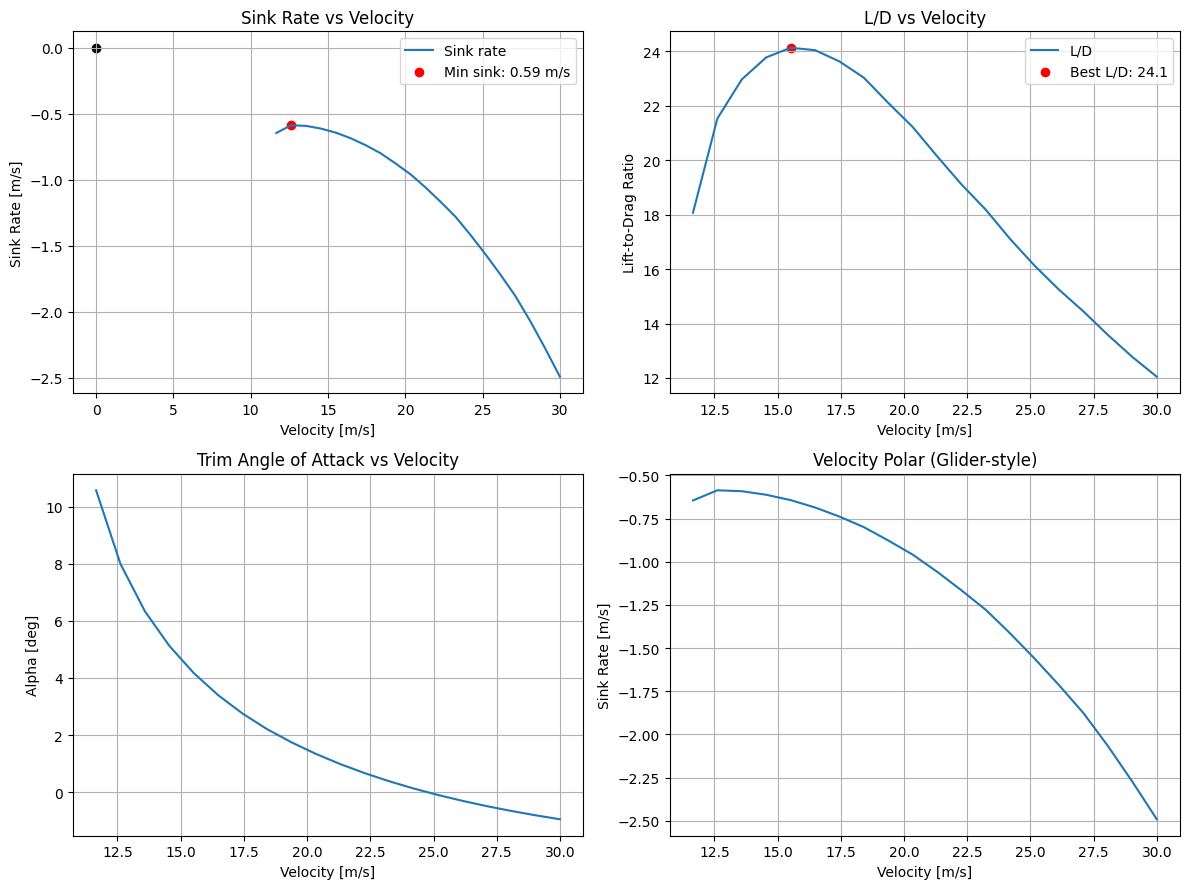


=== VELOCITY POLAR SUMMARY ===
Min sink speed   : 12.62 m/s
Min sink rate    : 0.59 m/s
Best glide speed : 15.52 m/s
Max L/D          : 24.13


In [12]:
velocities = np.linspace(2, 30, 30)

polar = analyze_velocity_polar(
    airplane=airplane,
    mass=1.5,
    velocities=velocities
)

In [13]:
op = asb.OperatingPoint(velocity=TARGET_VELOCITY, alpha=2)
ab = asb.AeroBuildup(  # This sets up the analysis, but doesn't execute calculation
    airplane=airplane,  # type: asb.Airplane
    op_point=op,  # type: asb.OperatingPoint
    xyz_ref=[results['x_cg'], 0, 0],  # Moment reference and center of rotation.
)
aero = ab.run()  # This executes the actual aero analysis.
aero_with_stability_derivs = ab.run_with_stability_derivatives() 

In [14]:
vlm.draw(backend='plotly')

NameError: name 'vlm' is not defined

In [ ]:
plot_wing_performance(results, airplane)

Wyniki analizy:
L/D: 30.41
Static Margin: 8.00%
Cn-beta (Boczna): 0.0145
Lift Coefficient: 0.2081
Trim moment Coefficient: 0.0185
Center of Gravity: 0.1716,
Neutral Point: 0.1842

Wyniki analizy:
L/D: 27.89
Static Margin: 8.00%
Cn-beta (Boczna): 0.0501
Lift Coefficient: 0.1957
Trim moment Coefficient: 0.0251
Center of Gravity: 0.1741,
Neutral Point: 0.1864


Wyniki analizy:
L/D: 18.52
Static Margin: 8.00%
Cn-beta (Boczna): 0.1460
Lift Coefficient: 0.2068
Trim moment Coefficient: 0.0050
Center of Gravity: 0.1753,
Neutral Point: 0.1877